In [ ]:
!pip install opendatasets opencv-python albumentations

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shutil
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K

In [ ]:
import opendatasets as od
ham_url = "https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000"
isic_url = "https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic"

print("Downloading HAM10000...")
od.download(ham_url)
print("Downloading ISIC 9 Classes...")
od.download(isic_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jasminnasser
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [00:50<00:00, 110MB/s] 



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: jasminnasser
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic


100%|██████████| 786M/786M [00:08<00:00, 102MB/s]


In [ ]:
master_dir = 'unified_dataset'
os.makedirs(master_dir, exist_ok=True)

ham_mapping = {'nv': 'melanocytic_nevi', 'mel': 'melanoma', 'bcc': 'basal_cell_carcinoma',
               'akiec': 'actinic_keratosis', 'bkl': 'benign_keratosis', 'df': 'dermatofibroma',
               'vasc': 'vascular_lesion'}

isic_mapping = {'actinic keratosis': 'actinic_keratosis', 'basal cell carcinoma': 'basal_cell_carcinoma',
                'dermatofibroma': 'dermatofibroma', 'melanoma': 'melanoma', 'nevus': 'melanocytic_nevi',
                'pigmented benign keratosis': 'benign_keratosis', 'seborrheic keratosis': 'benign_keratosis',
                'squamous cell carcinoma': 'actinic_keratosis', 'vascular lesion': 'vascular_lesion'}

ham_base = 'skin-cancer-mnist-ham10000'
metadata = pd.read_csv(f'{ham_base}/HAM10000_metadata.csv')
ham_folders = [f'{ham_base}/ham10000_images_part_1', f'{ham_base}/ham10000_images_part_2']

print("Processing HAM10000...")
for _, row in metadata.iterrows():
    label = ham_mapping[row['dx']]
    dest = os.path.join(master_dir, label)
    os.makedirs(dest, exist_ok=True)
    img_name = row['image_id'] + '.jpg'
    for folder in ham_folders:
        src = os.path.join(folder, img_name)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(dest, img_name))
            break

print("Processing ISIC 9 Classes...")
isic_root = 'skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration'
for split in ['Train', 'Test']:
    split_path = os.path.join(isic_root, split)
    if not os.path.exists(split_path): continue
    for folder_name in os.listdir(split_path):
        if folder_name in isic_mapping:
            target_label = isic_mapping[folder_name]
            dest_folder = os.path.join(master_dir, target_label)
            os.makedirs(dest_folder, exist_ok=True)
            src_folder = os.path.join(split_path, folder_name)
            for img in os.listdir(src_folder):
                safe_img_name = f"isic9_{split.lower()}_{img}"
                shutil.copy(os.path.join(src_folder, img), os.path.join(dest_folder, safe_img_name))

print(f"Done! Dataset ready in '{master_dir}' folder.")


Processing HAM10000...
Processing ISIC 9 Classes...
Done! Dataset ready in 'unified_dataset' folder.


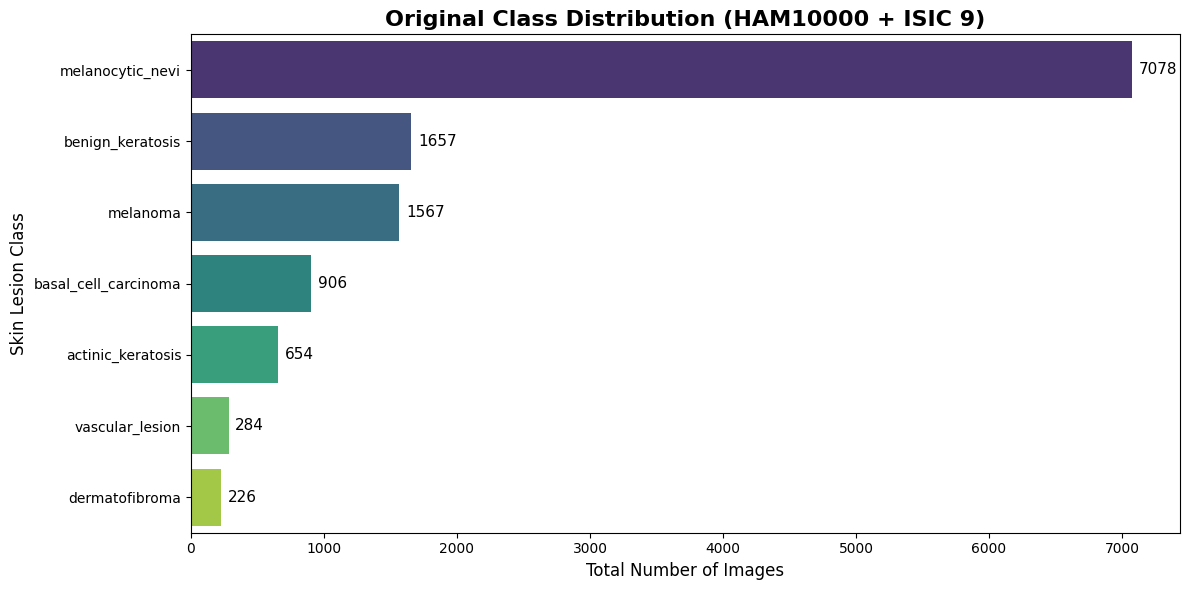

In [ ]:
master_dir = 'unified_dataset'
class_counts = {}

for folder_name in os.listdir(master_dir):
    folder_path = os.path.join(master_dir, folder_name)
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        class_counts[folder_name] = num_images

class_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()),
            hue=list(class_counts.keys()), palette="viridis", legend=False)
plt.title('Original Class Distribution (HAM10000 + ISIC 9)', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Images', fontsize=12)
plt.ylabel('Skin Lesion Class', fontsize=12)

for index, value in enumerate(class_counts.values()):
    plt.text(value + 50, index, str(value), va='center', fontsize=11)

plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv('/content/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

print(df.head())
print(df.info())
print(df.describe())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None
               age
count  9958.000000
mean  

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'bkl'),
  Text(1, 0, 'nv'),
  Text(2, 0, 'df'),
  Text(3, 0, 'mel'),
  Text(4, 0, 'vasc'),
  Text(5, 0, 'bcc'),
  Text(6, 0, 'akiec')])

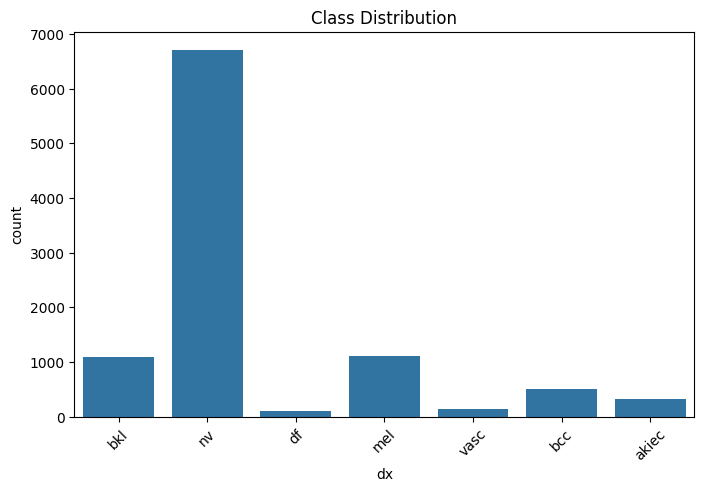

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='dx')
plt.title("Class Distribution")
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Age Distribution')

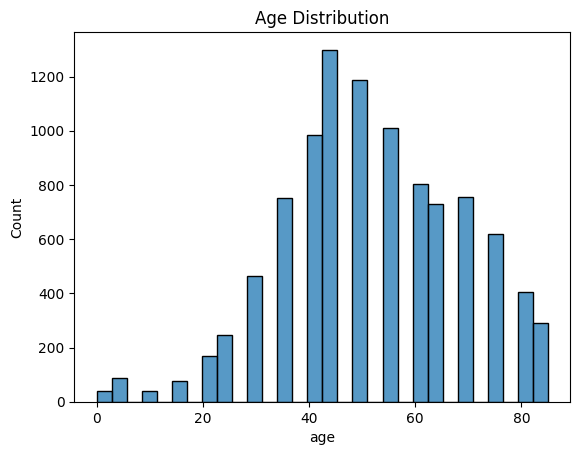

In [ ]:
sns.histplot(df['age'].dropna(), bins=30)
plt.title("Age Distribution")

In [ ]:
balanced_dir = 'balanced_dataset'
TARGET_COUNT =2000

if os.path.exists(balanced_dir):
    shutil.rmtree(balanced_dir)
os.makedirs(balanced_dir)

transform = A.Compose([
    A.Resize(224,224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=25, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.CLAHE(p=0.3),
    A.GaussNoise(p=0.2),
])

for class_name in os.listdir(master_dir):
    src_dir = os.path.join(master_dir, class_name)
    dst_dir = os.path.join(balanced_dir, class_name)
    os.makedirs(dst_dir, exist_ok=True)

    images = [img for img in os.listdir(src_dir) if img.endswith(('.jpg','.png','.jpeg'))]

    if len(images) >= TARGET_COUNT:
        selected = random.sample(images, TARGET_COUNT)

        for img in selected:
            shutil.copy(os.path.join(src_dir, img), os.path.join(dst_dir, img))

    else:
        for img in images:
            shutil.copy(os.path.join(src_dir, img), os.path.join(dst_dir, img))

        while len(os.listdir(dst_dir)) < TARGET_COUNT:
            img_name = random.choice(images)
            img_path = os.path.join(src_dir, img_name)

            img = cv2.imread(img_path)
            if img is None: continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            aug = transform(image=img)['image']
            aug = cv2.cvtColor(aug, cv2.COLOR_RGB2BGR)

            new_name = f"aug_{random.randint(0,999999)}.jpg"
            cv2.imwrite(os.path.join(dst_dir, new_name), aug)

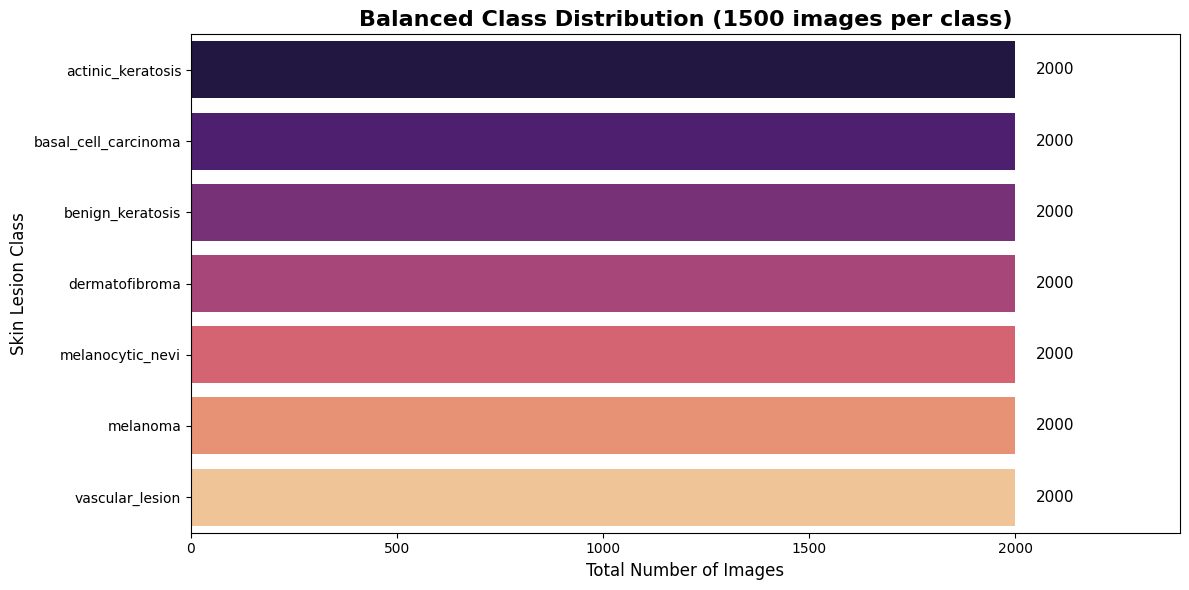

In [ ]:
balanced_dir = 'balanced_dataset'
class_counts = {}

for folder_name in os.listdir(balanced_dir):
    folder_path = os.path.join(balanced_dir, folder_name)
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        class_counts[folder_name] = num_images

class_counts = dict(sorted(class_counts.items()))

plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()),
            hue=list(class_counts.keys()), palette="magma", legend=False)
plt.title('Balanced Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Images', fontsize=12)
plt.ylabel('Skin Lesion Class', fontsize=12)

for index, value in enumerate(class_counts.values()):
    plt.text(value + 50, index, str(value), va='center', fontsize=11)

plt.xlim(0, max(class_counts.values()) + 400)
plt.tight_layout()
plt.show()


In [ ]:
def remove_hair(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, thresh = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img, thresh, 1, cv2.INPAINT_TELEA)
def segment_lesion(image):
    img = image.copy()
    mask = np.zeros(img.shape[:2], np.uint8)

    h, w = img.shape[:2]
    rect = (int(w*0.2), int(h*0.2), int(w*0.6), int(h*0.6))

    bgdModel = np.zeros((1,65), np.float64)
    fgdModel = np.zeros((1,65), np.float64)

    cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

    mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
    segmented = img * mask2[:, :, np.newaxis]

    return segmented

clean_dir = 'clean_dataset'
os.makedirs(clean_dir, exist_ok=True)

for class_name in os.listdir(balanced_dir):
    src = os.path.join(balanced_dir, class_name)
    dst = os.path.join(clean_dir, class_name)
    os.makedirs(dst, exist_ok=True)

    for img_name in os.listdir(src):
        img = cv2.imread(os.path.join(src, img_name))
        if img is None: continue
        img = remove_hair(img)
        img = segment_lesion(img)
        cv2.imwrite(os.path.join(dst, img_name), img)

In [ ]:
class_name = 'melanocytic_nevi'
class_path = os.path.join(clean_dir, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Sample after hair removal - {class_name}")
plt.axis('off')
plt.show()